# Gallego et al. (2020) — Long-term stability of cortical population dynamics

**Citation:** Gallego JA, Perich MG, Chowdhury RH, Solla SA, Miller LE.
"Long-term stability of cortical population dynamics underlying consistent behavior."
*Nature Neuroscience* 23, 260–270 (2020). https://doi.org/10.1038/s41593-019-0555-4

**Analysis replicated:** Cross-day stability of latent dynamics via CCA-based
normalized similarity (Fig. 4 analog).

**Adaptation:** Applied to MOp units aligned to lick onset (`response_time`) in the Allen
Dynamic Routing context-switching task (mice), not macaque reaching.
See `paper_replication_plan.md` for full deviation breakdown.

In [1]:
import numpy as np
import h5py
import fsspec
import yaml
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
from upath import UPath

np.random.seed(42)

BUCKET       = "s3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.273/"
YAML_PATH    = "MOp_sessions.yaml"
SUBJECTS     = ["667252", "668755", "708016", "746439", "759434"]
REGION       = "MOp"
T_START      = -0.120   # s before lick onset (paper M1: -120 ms before movement onset)
T_END        =  0.420   # s after  lick onset (paper M1: +420 ms after movement onset)
BIN_SIZE     =  0.030   # 30 ms bins (paper)
SMOOTH_MS    =  50.0    # Gaussian SD in ms (paper)
MIN_FR       =  1.0     # Hz — paper's firing-rate exclusion threshold
MIN_UNITS    =  5       # minimum MOp units to include a session
MIN_TRIALS   =  10      # minimum lick-aligned trials to include a session
VAR_THRESH   =  0.85    # choose N PCs to explain this fraction of variance
N_CCA_SPLITS =  100     # within-day trial splits for upper bound
N_TOP_CCS    =  4       # number of top CCs to average for normalized similarity

BINS = np.arange(T_START, T_END + BIN_SIZE, BIN_SIZE)
N_BINS = len(BINS) - 1
SIGMA_BINS = SMOOTH_MS / (BIN_SIZE * 1000)

print(f"Window: {T_START*1000:.0f} to {T_END*1000:.0f} ms  |  "
      f"{N_BINS} bins at {BIN_SIZE*1000:.0f} ms  |  σ={SIGMA_BINS:.2f} bins")
print(f"Subjects: {SUBJECTS}")

Window: -120 to 420 ms  |  18 bins at 30 ms  |  σ=1.67 bins
Subjects: ['667252', '668755', '708016', '746439', '759434']


## Step 1 — Load session paths from YAML

In [2]:
with open(YAML_PATH) as f:
    mop_yaml = yaml.safe_load(f)

# Build (subject, path) list for selected subjects only
session_list = []
for subj in SUBJECTS:
    for fname in mop_yaml.get(int(subj), mop_yaml.get(subj, [])):
        session_list.append((str(subj), UPath(BUCKET) / fname))

print(f"Sessions to load: {len(session_list)}")
for subj, path in session_list:
    print(f"  {subj}  {path.name}")

Sessions to load: 21
  667252  667252_2023-09-25.nwb
  667252  667252_2023-09-26.nwb
  667252  667252_2023-09-27.nwb
  667252  667252_2023-09-28.nwb
  668755  668755_2023-08-28.nwb
  668755  668755_2023-08-29.nwb
  668755  668755_2023-08-30.nwb
  668755  668755_2023-08-31.nwb
  708016  708016_2024-04-29.nwb
  708016  708016_2024-04-30.nwb
  708016  708016_2024-05-01.nwb
  708016  708016_2024-05-02.nwb
  746439  746439_2025-01-27.nwb
  746439  746439_2025-01-28.nwb
  746439  746439_2025-01-29.nwb
  746439  746439_2025-01-30.nwb
  746439  746439_2025-01-31.nwb
  759434  759434_2025-02-03.nwb
  759434  759434_2025-02-05.nwb
  759434  759434_2025-02-06.nwb
  759434  759434_2025-02-07.nwb


## Step 2 — Load spike times and lick events
Handles both NWB schema versions:
- **2023:** `units/location` present directly
- **2024+:** `location` only in `electrodes`; joined via `units/peak_electrode`

⚠️ long-running (~15–20 min for 5 subjects × 4–5 sessions)

In [3]:
def load_session(nwb_path, region, min_fr=1.0):
    """
    Returns:
        spike_times: list of sorted np.ndarray per passing unit
        lick_times:  np.ndarray of valid response_time values (seconds)
    """
    fs = fsspec.filesystem("s3", anon=True)
    with h5py.File(fs.open(str(nwb_path), "rb", block_size=2**23), "r") as f:
        ug = f["units"]
        qc      = ug["default_qc"][:]
        st_flat = ug["spike_times"][:]
        st_idx  = ug["spike_times_index"][:]

        # Region lookup — schema-version-aware
        if "location" in ug:
            locs = ug["location"][:]
        else:
            eg        = f["general"]["extracellular_ephys"]["electrodes"]
            elec_locs = eg["location"][:]
            peak_elec = ug["peak_electrode"][:].astype(int)
            locs      = elec_locs[peak_elec]

        locs_str = np.array([l.decode() if isinstance(l, bytes) else str(l) for l in locs])
        mask     = np.array([l.startswith(region) for l in locs_str]) & qc.astype(bool)
        unit_idx = np.where(mask)[0]

        session_end = float(st_flat[-1]) if len(st_flat) else 1.0
        spike_times = []
        for i in unit_idx:
            s  = int(st_idx[i - 1]) if i > 0 else 0
            e  = int(st_idx[i])
            st = np.sort(st_flat[s:e].astype(float))
            if len(st) / session_end >= min_fr:
                spike_times.append(st)

        tg            = f["intervals"]["trials"]
        response_time = tg["response_time"][:].astype(float)
        valid         = np.isfinite(response_time) & (response_time > 0)
        lick_times    = response_time[valid]

    return spike_times, lick_times

In [4]:
sessions = {}
for subj, path in session_list:
    name = path.stem
    print(f"Loading {name}...", end=" ", flush=True)
    try:
        spike_times, lick_times = load_session(path, REGION, MIN_FR)
        if len(spike_times) >= MIN_UNITS and len(lick_times) >= MIN_TRIALS:
            sessions[name] = {
                "spike_times": spike_times,
                "lick_times":  lick_times,
                "n_units":     len(spike_times),
                "n_trials":    len(lick_times),
                "subj":        subj,
                "path":        str(path),
            }
            print(f"{len(spike_times)} units, {len(lick_times)} lick trials")
        else:
            print(f"SKIP ({len(spike_times)} units, {len(lick_times)} trials)")
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\n{len(sessions)} sessions loaded across "
      f"{len({v['subj'] for v in sessions.values()})} subjects")

Loading 667252_2023-09-25... 

125 units, 121 lick trials
Loading 667252_2023-09-26... 

53 units, 211 lick trials
Loading 667252_2023-09-27... 

130 units, 216 lick trials
Loading 667252_2023-09-28... 

64 units, 170 lick trials
Loading 668755_2023-08-28... 

...

12 units, 270 lick trials
Loading 759434_2025-02-03... 

12 units, 150 lick trials
Loading 759434_2025-02-05... 

56 units, 187 lick trials
Loading 759434_2025-02-06... 

49 units, 168 lick trials
Loading 759434_2025-02-07... 

SKIP (0 units, 175 trials)

19 sessions loaded across 5 subjects


## Step 3 — Bin, square-root transform, Gaussian smooth
Faithful to paper: 30 ms bins → sqrt transform → 50 ms Gaussian smooth.

In [5]:
def bin_sqrt_smooth(spike_times_list, event_times, bins, sigma_bins):
    """Returns (n_units, n_trials, n_bins) — sqrt-transformed and Gaussian-smoothed."""
    n_units  = len(spike_times_list)
    n_trials = len(event_times)
    n_bins   = len(bins) - 1
    counts   = np.zeros((n_units, n_trials, n_bins), dtype=np.float32)
    for u, st in enumerate(spike_times_list):
        for t, t0 in enumerate(event_times):
            lo = np.searchsorted(st, t0 + bins[0])
            hi = np.searchsorted(st, t0 + bins[-1])
            if lo < hi:
                spk  = st[lo:hi] - t0
                bidx = np.clip(np.searchsorted(bins[1:], spk), 0, n_bins - 1)
                np.add.at(counts[u, t], bidx, 1)
    counts = np.sqrt(counts)
    counts = gaussian_filter1d(counts, sigma=sigma_bins, axis=-1)
    return counts

In [6]:
for name, sess in sessions.items():
    print(f"Binning {name}...", end=" ", flush=True)
    sess["rates"] = bin_sqrt_smooth(
        sess["spike_times"], sess["lick_times"], BINS, SIGMA_BINS
    )
    print(f"shape {sess['rates'].shape}")

Binning 667252_2023-09-25... 

shape (125, 121, 18)
Binning 667252_2023-09-26... 

shape (53, 211, 18)
Binning 667252_2023-09-27... 

shape (130, 216, 18)
Binning 667252_2023-09-28... 

shape (64, 170, 18)
Binning 668755_2023-08-28... 

...

shape (49, 243, 18)
Binning 746439_2025-01-31... 

shape (12, 270, 18)
Binning 759434_2025-02-03... 

shape (12, 150, 18)
Binning 759434_2025-02-05... 

shape (56, 187, 18)
Binning 759434_2025-02-06... 

shape (49, 168, 18)


## Step 4 — PCA per session
Data matrix X = (n_units × T), T = n_trials × n_bins.
N PCs chosen to explain ≥85% variance (adapted from paper's fixed M1=10).

In [7]:
def fit_pca(rates, var_thresh=0.85, max_pcs=20):
    """Returns components (n_pcs, n_units), latent (n_pcs, T), n_pcs, explained variance."""
    n_units, n_trials, n_bins = rates.shape
    X      = rates.reshape(n_units, -1)
    n_comp = min(n_units, max_pcs)
    pca    = PCA(n_components=n_comp, random_state=42)
    pca.fit(X.T)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_pcs  = max(3, min(int(np.searchsorted(cumvar, var_thresh)) + 1, max_pcs))
    comps  = pca.components_[:n_pcs]
    L      = comps @ X
    return comps, L, n_pcs, pca.explained_variance_ratio_

In [8]:
for name, sess in sessions.items():
    comps, L, n_pcs, evr = fit_pca(sess["rates"], VAR_THRESH)
    sess["comps"] = comps
    sess["L"]     = L
    sess["n_pcs"] = n_pcs
    sess["evr"]   = evr
    print(f"{name}: {n_pcs} PCs → {np.cumsum(evr)[n_pcs-1]:.1%} variance  "
          f"({sess['n_units']} units)")

667252_2023-09-25: 20 PCs → 68.9% variance  (125 units)
667252_2023-09-26: 20 PCs → 82.9% variance  (53 units)
667252_2023-09-27: 20 PCs → 67.8% variance  (130 units)
667252_2023-09-28: 20 PCs → 80.8% variance  (64 units)
668755_2023-08-28: 20 PCs → 61.7% variance  (116 units)
668755_2023-08-29: 20 PCs → 82.4% variance  (72 units)
668755_2023-08-30: 20 PCs → 58.5% variance  (189 units)
668755_2023-08-31: 20 PCs → 68.2% variance  (105 units)
708016_2024-04-29: 20 PCs → 70.4% variance  (65 units)
708016_2024-05-01: 20 PCs → 70.8% variance  (133 units)
708016_2024-05-02: 6 PCs → 87.1% variance  (11 units)
746439_2025-01-27: 20 PCs → 60.3% variance  (115 units)
746439_2025-01-28: 20 PCs → 77.7% variance  (65 units)
746439_2025-01-29: 20 PCs → 67.3% variance  (70 units)
746439_2025-01-30: 20 PCs → 84.6% variance  (49 units)
746439_2025-01-31: 8 PCs → 88.0% variance  (12 units)
759434_2025-02-03: 7 PCs → 86.2% variance  (12 units)
759434_2025-02-05: 20 PCs → 83.7% variance  (56 units)
759434

## Step 5 — CCA stability analysis
Normalized similarity = mean(top-4 across-day CCs) / mean(top-4 within-day CCs).

In [9]:
def cca_ccs(L_A, L_B, n_pcs):
    T      = min(L_A.shape[1], L_B.shape[1])
    Q_A, _ = np.linalg.qr(L_A[:, :T].T)
    Q_B, _ = np.linalg.qr(L_B[:, :T].T)
    _, S, _ = np.linalg.svd(Q_A.T @ Q_B, full_matrices=False)
    return np.clip(S[:n_pcs], 0, 1)


def within_day_upper_bound(sess, n_pcs, n_splits=100, seed=42):
    rng    = np.random.default_rng(seed)
    comps  = sess["comps"][:n_pcs]
    rates  = sess["rates"]
    n_units, n_trials, n_bins = rates.shape
    all_ccs = []
    for _ in range(n_splits):
        idx  = rng.permutation(n_trials)
        half = n_trials // 2
        X_A  = rates[:, idx[:half],       :].reshape(n_units, -1)
        X_B  = rates[:, idx[half:2*half], :].reshape(n_units, -1)
        all_ccs.append(cca_ccs(comps @ X_A, comps @ X_B, n_pcs))
    return np.mean(all_ccs, axis=0)

In [10]:
results = {}

for subj in SUBJECTS:
    subj_sess  = {k: v for k, v in sessions.items() if v["subj"] == subj}
    day_names  = sorted(subj_sess.keys())
    n_days     = len(day_names)

    if n_days < 2:
        print(f"\nSubject {subj}: {n_days} eligible session(s) — skipping.")
        results[subj] = None
        continue

    n_pcs = min(v["n_pcs"] for v in subj_sess.values())
    print(f"\nSubject {subj}: {n_days} sessions, N PCs = {n_pcs}")

    within_ccs = {}
    for name in day_names:
        wcc = within_day_upper_bound(subj_sess[name], n_pcs, N_CCA_SPLITS)
        within_ccs[name] = wcc
        print(f"  {name} within-day top-{N_TOP_CCS}: {wcc[:N_TOP_CCS].round(3)}")

    pairs = []
    for i, na in enumerate(day_names):
        for nb in day_names[i + 1:]:
            sa, sb = subj_sess[na], subj_sess[nb]
            L_a = sa["comps"][:n_pcs] @ sa["rates"].reshape(sa["n_units"], -1)
            L_b = sb["comps"][:n_pcs] @ sb["rates"].reshape(sb["n_units"], -1)
            ccs = cca_ccs(L_a, L_b, n_pcs)

            within_avg = (within_ccs[na][:N_TOP_CCS] + within_ccs[nb][:N_TOP_CCS]) / 2
            norm_sim   = np.mean(ccs[:N_TOP_CCS]) / np.mean(within_avg)
            gap        = day_names.index(nb) - day_names.index(na)

            pairs.append({"day_a": na, "day_b": nb, "gap": gap,
                          "ccs": ccs, "norm_sim": norm_sim})
            print(f"  {na} ↔ {nb} (gap={gap}d): norm_sim={norm_sim:.3f}")

    results[subj] = {"pairs": pairs, "within_ccs": within_ccs,
                     "n_pcs": n_pcs, "day_names": day_names}


Subject 667252: 4 sessions, N PCs = 20


  667252_2023-09-25 within-day top-4: [0.987 0.739 0.565 0.51 ]


  667252_2023-09-26 within-day top-4: [0.974 0.518 0.421 0.375]


  667252_2023-09-27 within-day top-4: [0.986 0.643 0.463 0.416]
  667252_2023-09-28 within-day top-4: [0.976 0.584 0.475 0.431]
  667252_2023-09-25 ↔ 667252_2023-09-26 (gap=1d): norm_sim=0.979
  667252_2023-09-25 ↔ 667252_2023-09-27 (gap=2d): norm_sim=0.995
  667252_2023-09-25 ↔ 667252_2023-09-28 (gap=3d): norm_sim=0.949
  667252_2023-09-26 ↔ 667252_2023-09-27 (gap=1d): norm_sim=0.928
  667252_2023-09-26 ↔ 667252_2023-09-28 (gap=2d): norm_sim=0.917
  667252_2023-09-27 ↔ 667252_2023-09-28 (gap=1d): norm_sim=0.965

Subject 668755: 4 sessions, N PCs = 20


  668755_2023-08-28 within-day top-4: [0.972 0.698 0.414 0.365]


...

  668755_2023-08-30 within-day top-4: [0.983 0.757 0.577 0.418]


  668755_2023-08-31 within-day top-4: [0.986 0.692 0.483 0.383]
  668755_2023-08-28 ↔ 668755_2023-08-29 (gap=1d): norm_sim=1.016
  668755_2023-08-28 ↔ 668755_2023-08-30 (gap=2d): norm_sim=1.029
  668755_2023-08-28 ↔ 668755_2023-08-31 (gap=3d): norm_sim=1.011
  668755_2023-08-29 ↔ 668755_2023-08-30 (gap=1d): norm_sim=1.024
  668755_2023-08-29 ↔ 668755_2023-08-31 (gap=2d): norm_sim=1.046
  668755_2023-08-30 ↔ 668755_2023-08-31 (gap=1d): norm_sim=1.052

Subject 708016: 3 sessions, N PCs = 6
  708016_2024-04-29 within-day top-4: [0.968 0.425 0.247 0.147]
  708016_2024-05-01 within-day top-4: [0.969 0.716 0.477 0.184]


  708016_2024-05-02 within-day top-4: [0.64  0.199 0.139 0.093]
  708016_2024-04-29 ↔ 708016_2024-05-01 (gap=1d): norm_sim=0.854
  708016_2024-04-29 ↔ 708016_2024-05-02 (gap=2d): norm_sim=0.841
  708016_2024-05-01 ↔ 708016_2024-05-02 (gap=1d): norm_sim=0.838

Subject 746439: 5 sessions, N PCs = 8
  746439_2025-01-27 within-day top-4: [0.976 0.354 0.271 0.213]
  746439_2025-01-28 within-day top-4: [0.973 0.352 0.22  0.158]


  746439_2025-01-29 within-day top-4: [0.977 0.422 0.19  0.143]
  746439_2025-01-30 within-day top-4: [0.965 0.392 0.215 0.159]
  746439_2025-01-31 within-day top-4: [0.942 0.246 0.171 0.129]
  746439_2025-01-27 ↔ 746439_2025-01-28 (gap=1d): norm_sim=0.964
  746439_2025-01-27 ↔ 746439_2025-01-29 (gap=2d): norm_sim=0.948
  746439_2025-01-27 ↔ 746439_2025-01-30 (gap=3d): norm_sim=1.022
  746439_2025-01-27 ↔ 746439_2025-01-31 (gap=4d): norm_sim=0.938
  746439_2025-01-28 ↔ 746439_2025-01-29 (gap=1d): norm_sim=0.895
  746439_2025-01-28 ↔ 746439_2025-01-30 (gap=2d): norm_sim=0.941
  746439_2025-01-28 ↔ 746439_2025-01-31 (gap=3d): norm_sim=0.929
  746439_2025-01-29 ↔ 746439_2025-01-30 (gap=1d): norm_sim=0.965
  746439_2025-01-29 ↔ 746439_2025-01-31 (gap=2d): norm_sim=0.899
  746439_2025-01-30 ↔ 746439_2025-01-31 (gap=1d): norm_sim=0.931

Subject 759434: 3 sessions, N PCs = 7


  759434_2025-02-03 within-day top-4: [0.805 0.252 0.188 0.139]
  759434_2025-02-05 within-day top-4: [0.924 0.644 0.259 0.177]
  759434_2025-02-06 within-day top-4: [0.963 0.548 0.378 0.188]
  759434_2025-02-03 ↔ 759434_2025-02-05 (gap=1d): norm_sim=0.863
  759434_2025-02-03 ↔ 759434_2025-02-06 (gap=2d): norm_sim=0.798
  759434_2025-02-05 ↔ 759434_2025-02-06 (gap=1d): norm_sim=0.971


In [ ]:
# Save results so downstream cells can be re-run without reloading spike data
import numpy as np
np.save("results_cache.npy", {
    "results":  results,
    "sessions_meta": {
        name: {
            "subj":    sess["subj"],
            "n_units": sess["n_units"],
            "n_trials": sess["n_trials"],
            "n_pcs":   sess["n_pcs"],
            "evr":     sess["evr"],
        }
        for name, sess in sessions.items()
    }
}, allow_pickle=True)
print("Saved results_cache.npy")

## Results — Normalized similarity vs. days apart

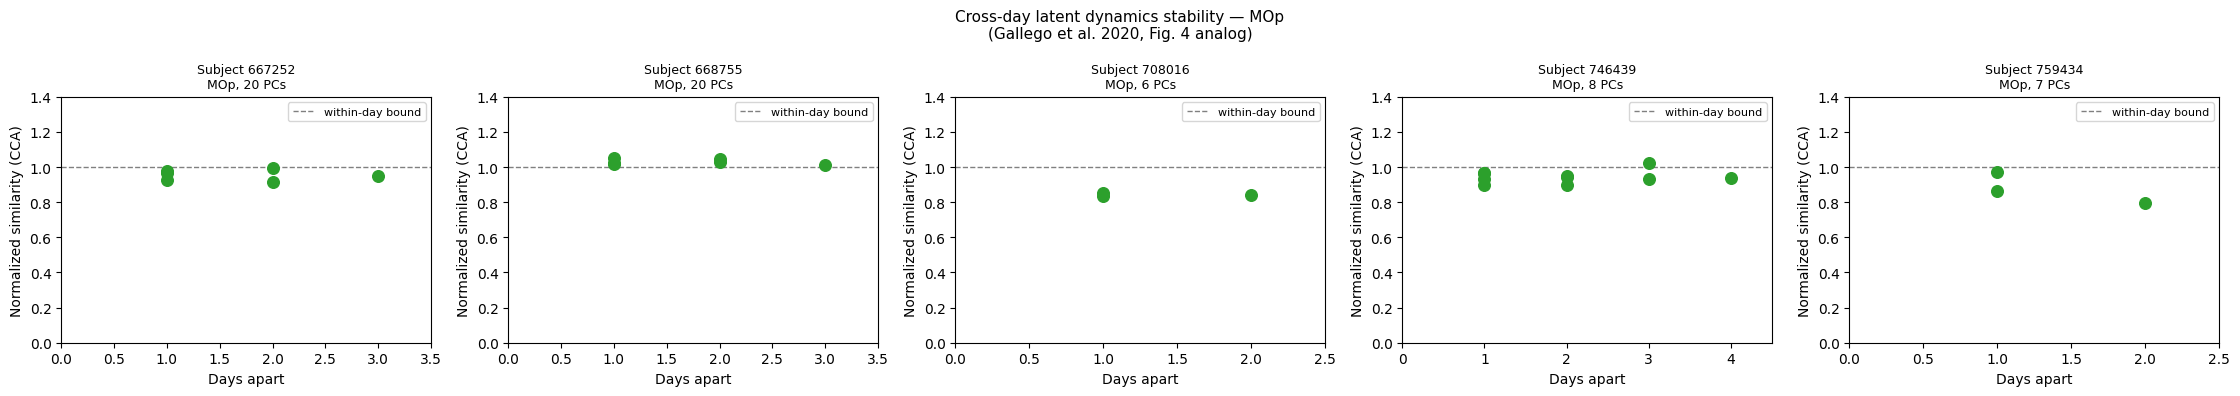

Saved: stability_mop.png


In [11]:
eligible = [s for s in SUBJECTS if results.get(s)]
n_subj   = len(eligible)
fig, axes = plt.subplots(1, n_subj, figsize=(4.5 * n_subj, 4), squeeze=False)

for ax, subj in zip(axes[0], eligible):
    res   = results[subj]
    pairs = res["pairs"]
    gaps  = [p["gap"] for p in pairs]
    sims  = [p["norm_sim"] for p in pairs]

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1,
               label="within-day bound")
    ax.scatter(gaps, sims, color="#2ca02c", s=70, zorder=3)

    ax.set_xlabel("Days apart", fontsize=10)
    ax.set_ylabel("Normalized similarity (CCA)", fontsize=10)
    ax.set_title(f"Subject {subj}\nMOp, {res['n_pcs']} PCs", fontsize=9)
    ax.set_ylim(0, 1.4)
    ax.set_xlim(0, max(gaps) + 0.5)
    ax.legend(fontsize=8)

fig.suptitle("Cross-day latent dynamics stability — MOp\n"
             "(Gallego et al. 2020, Fig. 4 analog)", fontsize=11)
plt.tight_layout()
plt.savefig("stability_mop.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stability_mop.png")

## Results — Raw canonical correlations per subject

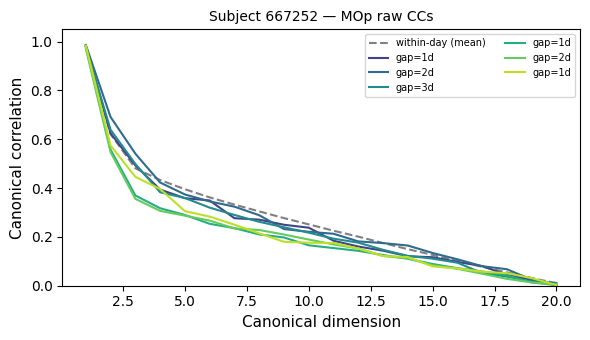

Saved: raw_ccs_667252.png


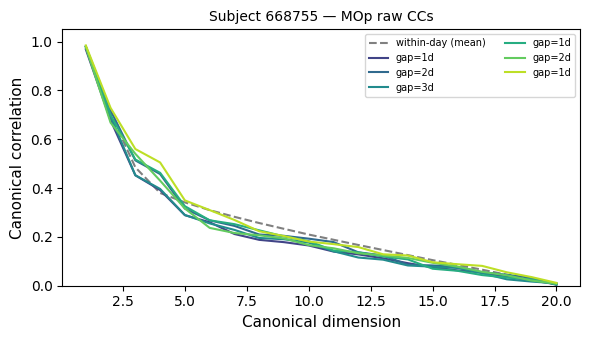

Saved: raw_ccs_668755.png


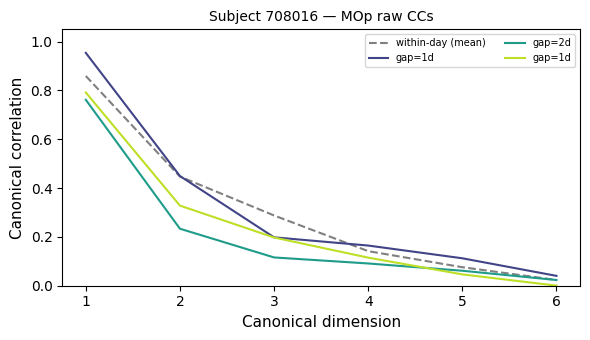

Saved: raw_ccs_708016.png


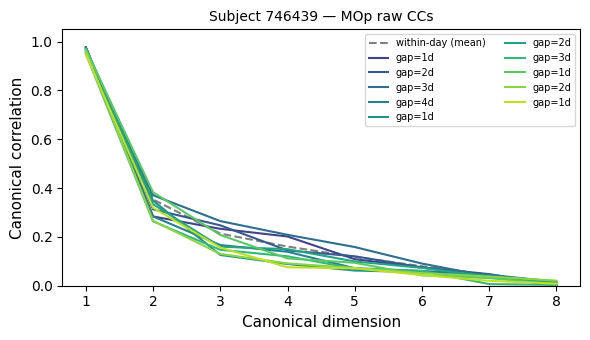

Saved: raw_ccs_746439.png


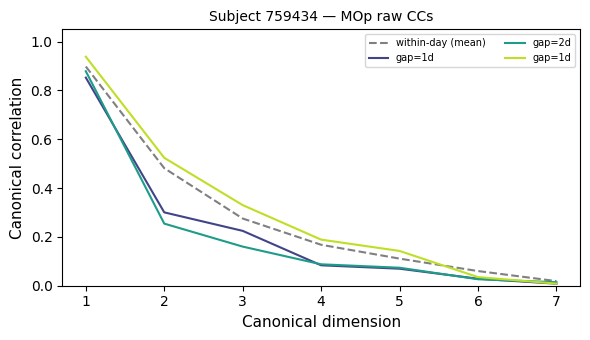

Saved: raw_ccs_759434.png


In [12]:
for subj in eligible:
    res    = results[subj]
    pairs  = res["pairs"]
    n_pcs  = res["n_pcs"]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    x = np.arange(1, n_pcs + 1)

    wcc_mean = np.mean([res["within_ccs"][d] for d in res["day_names"]], axis=0)
    ax.plot(x, wcc_mean[:n_pcs], color="gray", linestyle="--",
            linewidth=1.5, label="within-day (mean)")

    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(pairs)))
    for p, c in zip(pairs, colors):
        ax.plot(x, p["ccs"][:n_pcs], color=c, linewidth=1.5,
                label=f"gap={p['gap']}d")

    ax.set_xlabel("Canonical dimension", fontsize=11)
    ax.set_ylabel("Canonical correlation", fontsize=11)
    ax.set_title(f"Subject {subj} — MOp raw CCs", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    plt.tight_layout()
    fname = f"raw_ccs_{subj}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Analysis — Variance explained per session
Cumulative variance explained vs. number of PCs for every session.
The vertical marker shows the chosen N PCs (≥85% threshold).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

subj_colors = {
    subj: c for subj, c in zip(
        SUBJECTS,
        plt.cm.tab10(np.linspace(0, 0.9, len(SUBJECTS)))
    )
}

fig, ax = plt.subplots(figsize=(7, 4))

for name, sess in sorted(sessions.items()):
    subj  = sess["subj"]
    evr   = sess["evr"]
    n_pcs = sess["n_pcs"]
    cumvar = np.cumsum(evr)
    x = np.arange(1, len(cumvar) + 1)
    ax.plot(x, cumvar, color=subj_colors[subj], alpha=0.6, linewidth=1.2)
    ax.axvline(n_pcs, color=subj_colors[subj], alpha=0.3, linestyle=":")
    ax.scatter([n_pcs], [cumvar[n_pcs - 1]],
               color=subj_colors[subj], s=40, zorder=3)

ax.axhline(VAR_THRESH, color="black", linestyle="--", linewidth=1,
           label=f"{VAR_THRESH:.0%} threshold")

# Legend: one entry per subject
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=subj_colors[s], linewidth=2, label=f"Subj {s}")
           for s in SUBJECTS if any(v["subj"] == s for v in sessions.values())]
handles.append(Line2D([0],[0], color="black", linestyle="--", linewidth=1,
                      label=f"{VAR_THRESH:.0%} threshold"))
ax.legend(handles=handles, fontsize=8, loc="lower right")

ax.set_xlabel("Number of PCs", fontsize=11)
ax.set_ylabel("Cumulative variance explained", fontsize=11)
ax.set_title("Variance explained per session — MOp", fontsize=11)
ax.set_xlim(1, 21)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: variance_explained.png")

## Analysis — Stability vs. N units and N PCs
Each point is one cross-day pair. Checks whether lower unit counts or fewer PCs
explain lower normalized similarity.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten all pairs across subjects
all_pairs = []
for subj in SUBJECTS:
    res = results.get(subj)
    if res is None:
        continue
    for p in res["pairs"]:
        na, nb = p["day_a"], p["day_b"]
        n_units_a = sessions[na]["n_units"]
        n_units_b = sessions[nb]["n_units"]
        all_pairs.append({
            "subj":      subj,
            "gap":       p["gap"],
            "norm_sim":  p["norm_sim"],
            "n_units_min": min(n_units_a, n_units_b),
            "n_units_mean": (n_units_a + n_units_b) / 2,
            "n_pcs":     res["n_pcs"],
        })

subj_colors = {
    subj: c for subj, c in zip(
        SUBJECTS,
        plt.cm.tab10(np.linspace(0, 0.9, len(SUBJECTS)))
    )
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: stability vs N units
ax = axes[0]
for p in all_pairs:
    ax.scatter(p["n_units_min"], p["norm_sim"],
               color=subj_colors[p["subj"]], s=60, alpha=0.8,
               label=f"Subj {p['subj']}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Min N units across day pair", fontsize=11)
ax.set_ylabel("Normalized similarity (CCA)", fontsize=11)
ax.set_title("Stability vs. N units", fontsize=11)
ax.set_ylim(0.5, 1.3)

# Right: stability vs N PCs
ax = axes[1]
for p in all_pairs:
    ax.scatter(p["n_pcs"], p["norm_sim"],
               color=subj_colors[p["subj"]], s=60, alpha=0.8,
               label=f"Subj {p['subj']}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("N PCs used for CCA", fontsize=11)
ax.set_ylabel("Normalized similarity (CCA)", fontsize=11)
ax.set_title("Stability vs. N PCs", fontsize=11)
ax.set_ylim(0.5, 1.3)

# Shared legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color="w",
                  markerfacecolor=subj_colors[s], markersize=8, label=f"Subj {s}")
           for s in SUBJECTS if any(p["subj"] == s for p in all_pairs)]
fig.legend(handles=handles, fontsize=8, loc="lower center",
           ncol=len(handles), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("stability_vs_units_pcs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stability_vs_units_pcs.png")

# Print summary table
print(f"\n{'Subj':>8} {'N PCs':>6} {'N units (min)':>14} {'norm_sim':>10} {'gap':>5}")
for p in sorted(all_pairs, key=lambda x: (x["subj"], x["gap"])):
    print(f"{p['subj']:>8} {p['n_pcs']:>6} {p['n_units_min']:>14} "
          f"{p['norm_sim']:>10.3f} {p['gap']:>5}")

In [ ]:
# Stability vs. variance explained
# x = mean cumulative variance explained at N PCs (across the two sessions in each pair)
# y = normalized similarity

import matplotlib.pyplot as plt
import numpy as np

var_exp_pairs = []
for subj in SUBJECTS:
    res = results.get(subj)
    if res is None:
        continue
    for p in res["pairs"]:
        na, nb = p["day_a"], p["day_b"]
        n_pcs = res["n_pcs"]
        var_a = float(np.cumsum(sessions[na]["evr"])[n_pcs - 1])
        var_b = float(np.cumsum(sessions[nb]["evr"])[n_pcs - 1])
        var_exp_pairs.append({
            "subj":     subj,
            "gap":      p["gap"],
            "norm_sim": p["norm_sim"],
            "var_exp":  (var_a + var_b) / 2,
        })

subj_colors = {
    subj: c for subj, c in zip(
        SUBJECTS,
        plt.cm.tab10(np.linspace(0, 0.9, len(SUBJECTS)))
    )
}

fig, ax = plt.subplots(figsize=(5.5, 4))
for p in var_exp_pairs:
    ax.scatter(p["var_exp"] * 100, p["norm_sim"],
               color=subj_colors[p["subj"]], s=60, alpha=0.8)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="within-day bound")
ax.set_xlabel("Mean variance explained at N PCs (%)", fontsize=11)
ax.set_ylabel("Normalized similarity (CCA)", fontsize=11)
ax.set_title("Stability vs. variance explained — MOp", fontsize=11)
ax.set_ylim(0.5, 1.3)

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color="w",
                  markerfacecolor=subj_colors[s], markersize=8, label=f"Subj {s}")
           for s in SUBJECTS if any(p["subj"] == s for p in var_exp_pairs)]
handles.append(Line2D([0],[0], color="gray", linestyle="--", linewidth=1,
                      label="within-day bound"))
ax.legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.savefig("stability_vs_variance_explained.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stability_vs_variance_explained.png")

for p in sorted(var_exp_pairs, key=lambda x: x["var_exp"]):
    print(f"  subj={p['subj']}  var_exp={p['var_exp']:.1%}  "
          f"norm_sim={p['norm_sim']:.3f}  gap={p['gap']}d")

## Deviations

**Faithful:**
- 30 ms bins, 50 ms Gaussian smooth, square-root transform — exact paper values
- CCA normalized similarity: across-day / within-day, top-4 CCs averaged
- Within-day upper bound via 100 random trial splits
- FR > 1 Hz unit exclusion

**Adapted:**
- Species/task: macaque reaching → mouse context-switching sensory decision
- Brain region: macaque M1 → mouse MOp
- Trial alignment: movement onset → lick onset (`response_time`); miss trials excluded
- N PCs: paper's fixed 10 → ≥85% variance threshold per subject
- Unit tracking: paper had same implant across days; DR has daily re-insertions

**Uncertain:**
- Whether `default_qc` matches paper's waveform/ISI quality criteria
- MOp unit counts vary widely across sessions — may inflate noise in low-unit sessions
- `response_time` is first lick after stimulus; may not be purely motor output